# Installation of CALFEM and GMSH

In [ ]:
!DEBIAN_FRONTEND=noninteractive apt -qq install libglu1
!pip install calfem-python --quiet

The following NEW packages will be installed:
  libglu1-mesa
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 145 kB of archives.
After this operation, 367 kB of additional disk space will be used.
Selecting previously unselected package libglu1-mesa:amd64.
(Reading database ... 121752 files and directories currently installed.)
Preparing to unpack .../libglu1-mesa_9.0.2-1_amd64.deb ...
Unpacking libglu1-mesa:amd64 (9.0.2-1) ...
Setting up libglu1-mesa:amd64 (9.0.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.4) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind

# Mesh generation - Example 1

Shows how to create simple geometry from splines and ellipse arcs, and how to mesh a quad mesh in GmshMesher. Also demonstrates drawGeometry(), drawMesh, and drawing texts and labels in a figure.

## Required CALFEM modules

In [ ]:
import calfem.geometry as cfg
import calfem.mesh as cfm
import calfem.vis_mpl as cfv

Could not import Matplotlib backends. Probarbly due to missing Qt.


## Define geometry

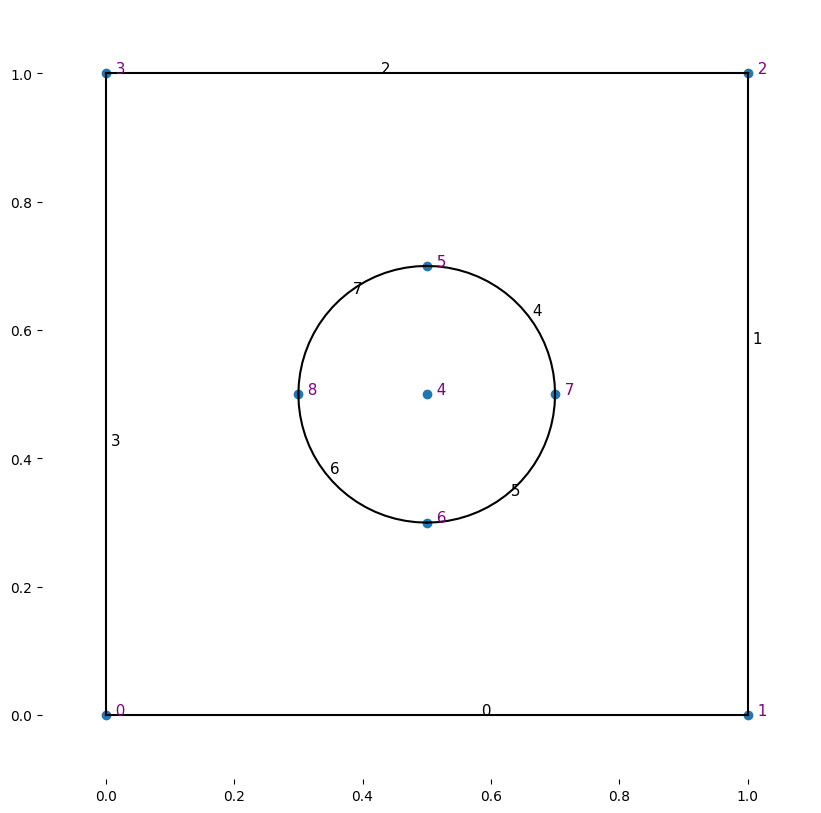

In [ ]:
g = cfg.Geometry()

# Add points

g.point([0, 0]) # 0
g.point([1, 0]) # 1
g.point([1, 1]) # 2
g.point([0, 1]) # 3

# Add points for circle

r = 0.20

g.point([0.5, 0.5])   # 4
g.point([0.5, 0.5+r]) # 5
g.point([0.5, 0.5-r]) # 6
g.point([0.5+r, 0.5]) # 7
g.point([0.5-r, 0.5]) # 8

# Add lines

g.spline([0, 1]) # 0
g.spline([1, 2]) # 1
g.spline([2, 3]) # 2
g.spline([3, 0]) # 3

# TODO: Add circles HERE

g.circle([5, 4, 7]) # 4
g.circle([7, 4, 6]) # 5
g.circle([6, 4, 8]) # 6
g.circle([8, 4, 5]) # 7

# Add surface and hole UPDATE

g.surface([0, 1, 2, 3], [[7, 6, 5, 4]])

cfv.figure(fig_size=(10.0,10.0))
cfv.draw_geometry(g)

---
# Exercise 1 - Creating a circular hole

Modify the code above to create circle arcs from points 4..8 to create a complete circle using the .circle() method.

Note that circle arcs can't be larger than pi.

Finally modify the .surface() method to use the circle arcs to define a hole in the mesh. Not that the circle arcs defining the circular hole must be given in counter-clockwise order.

Documentation for the geometry module can be found here:

[CALFEM Python - Docs](https://calfem-for-python.readthedocs.io/en/latest/calfem_reference.html#module-calfem.vis_mpl)

---

In [ ]:
#@title Click below to for a solution
g = cfg.Geometry()

# Add points

g.point([0, 0]) # 0
g.point([1, 0]) # 1
g.point([1, 1]) # 2
g.point([0, 1]) # 3

# Add points for circle

r = 0.25

g.point([0.5, 0.5])   # 4
g.point([0.5, 0.5+r]) # 5
g.point([0.5, 0.5-r]) # 6
g.point([0.5+r, 0.5]) # 7
g.point([0.5-r, 0.5]) # 8

# Add lines

g.spline([0, 1]) # 0
g.spline([1, 2]) # 1
g.spline([2, 3]) # 2
g.spline([3, 0]) # 3

# TODO: Add circles HERE

g.circle([5, 4, 7]) # 4
g.circle([7, 4, 6]) # 5
g.circle([6, 4, 8]) # 6
g.circle([8, 4, 5]) # 7

# Add surface and hole UPDATE

g.surface([0, 1, 2, 3], [[7, 6, 5, 4]])

cfv.figure(fig_size=(10.0,10.0))
cfv.draw_geometry(g)

# Generate mesh



In [ ]:
mesh = cfm.GmshMesh(g)

# Mesh properties

mesh.el_type = 3
mesh.dofs_per_node = 1  # Degrees of freedom per node.
mesh.el_size_factor = 0.020  # Factor that changes element sizes.

coords, edof, dofs, bdofs, elementmarkers = mesh.create()

cfv.figure(fig_size=(10,10))
cfv.draw_mesh(
    coords=coords,
    edof=edof,
    dofs_per_node=mesh.dofs_per_node,
    el_type=mesh.el_type,
    filled=True,
    title="Example 01"
)

Element type 3 is quad. 2 is triangle. See user manual for more element types)

---

# Exercise 2 - Updating mesh properties

Modify the code above to generate triangular elements with a more coarse element distribution.

---